**This notebook consists of EDA of IBM HR Attrition**




1.   Importing libraries and loading dataset into dataframe
2.   Checking no of rows and columns

3.   Taking a sneak peak on the data

1.   Removing irrelevent columns


2.   Checking data type of columns and checking the count of non zero elements in each column


1.   Checking missing/null values
2.   Checking duplicate rows








In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('D:/IBM HR Attrition/IBM_HR_dataset.csv') # Load dataset into DataFrame


In [3]:
df.shape # Return no of rows and columns

(1470, 35)

In [4]:
df.head() # Have a sneak peak on the dataset

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Removing irrelevent columns as they are not required.

In [5]:
df = df.drop(columns=['EmployeeCount','EmployeeNumber','StandardHours','Over18','HourlyRate','DailyRate','MonthlyRate'], errors = 'ignore')

In [6]:
df.info() # Getting info about non null/zero values and data types of each column

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   Department                1470 non-null   str  
 4   DistanceFromHome          1470 non-null   int64
 5   Education                 1470 non-null   int64
 6   EducationField            1470 non-null   str  
 7   EnvironmentSatisfaction   1470 non-null   int64
 8   Gender                    1470 non-null   str  
 9   JobInvolvement            1470 non-null   int64
 10  JobLevel                  1470 non-null   int64
 11  JobRole                   1470 non-null   str  
 12  JobSatisfaction           1470 non-null   int64
 13  MaritalStatus             1470 non-null   str  
 14  MonthlyIncome             1470 non-null   int64
 15

In [7]:
df.duplicated().sum()    # checking duplicate rows

np.int64(0)

In [8]:
df.isna().sum().sum()  # checking missing values

np.int64(0)

We do get that there are no missing values in the dataset as per **.isna()** function. But we also need to make sure that there are no string based placeholders occupying space and as it occupies space as .isna() actually bypasses it and considers as **non_null**. So to counter this issue we use **Type Coercion** for **int** data type columns and **.unique()** for **object** data type columns as we get all the unique entries per column and we identify suspicious placeholders and replace them and this make sure that missing values are completely handled.

In [9]:
# For int data type columns
int_columns = df.select_dtypes(include='int64').columns  #put all numeric columns in one and then check
df[int_columns] = df[int_columns].apply(pd.to_numeric,errors='coerce')
df[int_columns].isna().sum().sum()

np.int64(0)

Now we've checked each numeric column(**int64**) by **type coercion** and got that there are no placeholder missing values and no **NaN** or **Null** values.

In **object** data type based columns there is one issue which still persists and that is of empty string or a space as it is difficult to trace with .unique() so we strip the space with .str.strip() and then we replace it with **NaN** which can be traced by .isna()

In [10]:
# For object data type columns
for col in df.select_dtypes(include='object').columns :
  print(f"\n{col}:")
  print(df[col].unique())


Attrition:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

BusinessTravel:
<StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str

Department:
<StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str

EducationField:
<StringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str

Gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

JobRole:
<StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str

MaritalStatus:
<StringArray>
['Single', 'Married', 'Divorced']
Length: 3, dtype: str

OverTime:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


Here we get all the unique entries for each column and we can also check for suspicious placeholders.

In [11]:
# Stripping away blank spaces and replacing with np.nan
for col in df.select_dtypes(include='object').columns :
  df[col] = df[col].str.strip(" ") # remove space
  df[col] = df[col].replace("",np.nan) # replacing empty spaces with nan so .isna() can detect
df.isna().sum().sum()

np.int64(0)

We've now successfully completed the check of missing values in the entire dataset

In [12]:
df.describe()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,9.192517,2.912925,2.721769,2.729932,2.063946,2.728571,6502.931293,2.693197,15.209524,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,8.106864,1.024165,1.093082,0.711561,1.106940,1.102846,4707.956783,2.498009,3.659938,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,0.000000,11.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2911.000000,1.000000,12.000000,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,7.000000,3.000000,3.000000,3.000000,2.000000,3.000000,4919.000000,2.000000,14.000000,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,14.000000,4.000000,4.000000,3.000000,3.000000,4.000000,8379.000000,4.000000,18.000000,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,29.000000,5.000000,4.000000,4.000000,5.000000,4.000000,19999.000000,9.000000,25.000000,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


We now get some brief idea about the data categorically which includes the total rows in each column , what value is the most repeated and also the count of unique values per column

**Univariate Analysis**

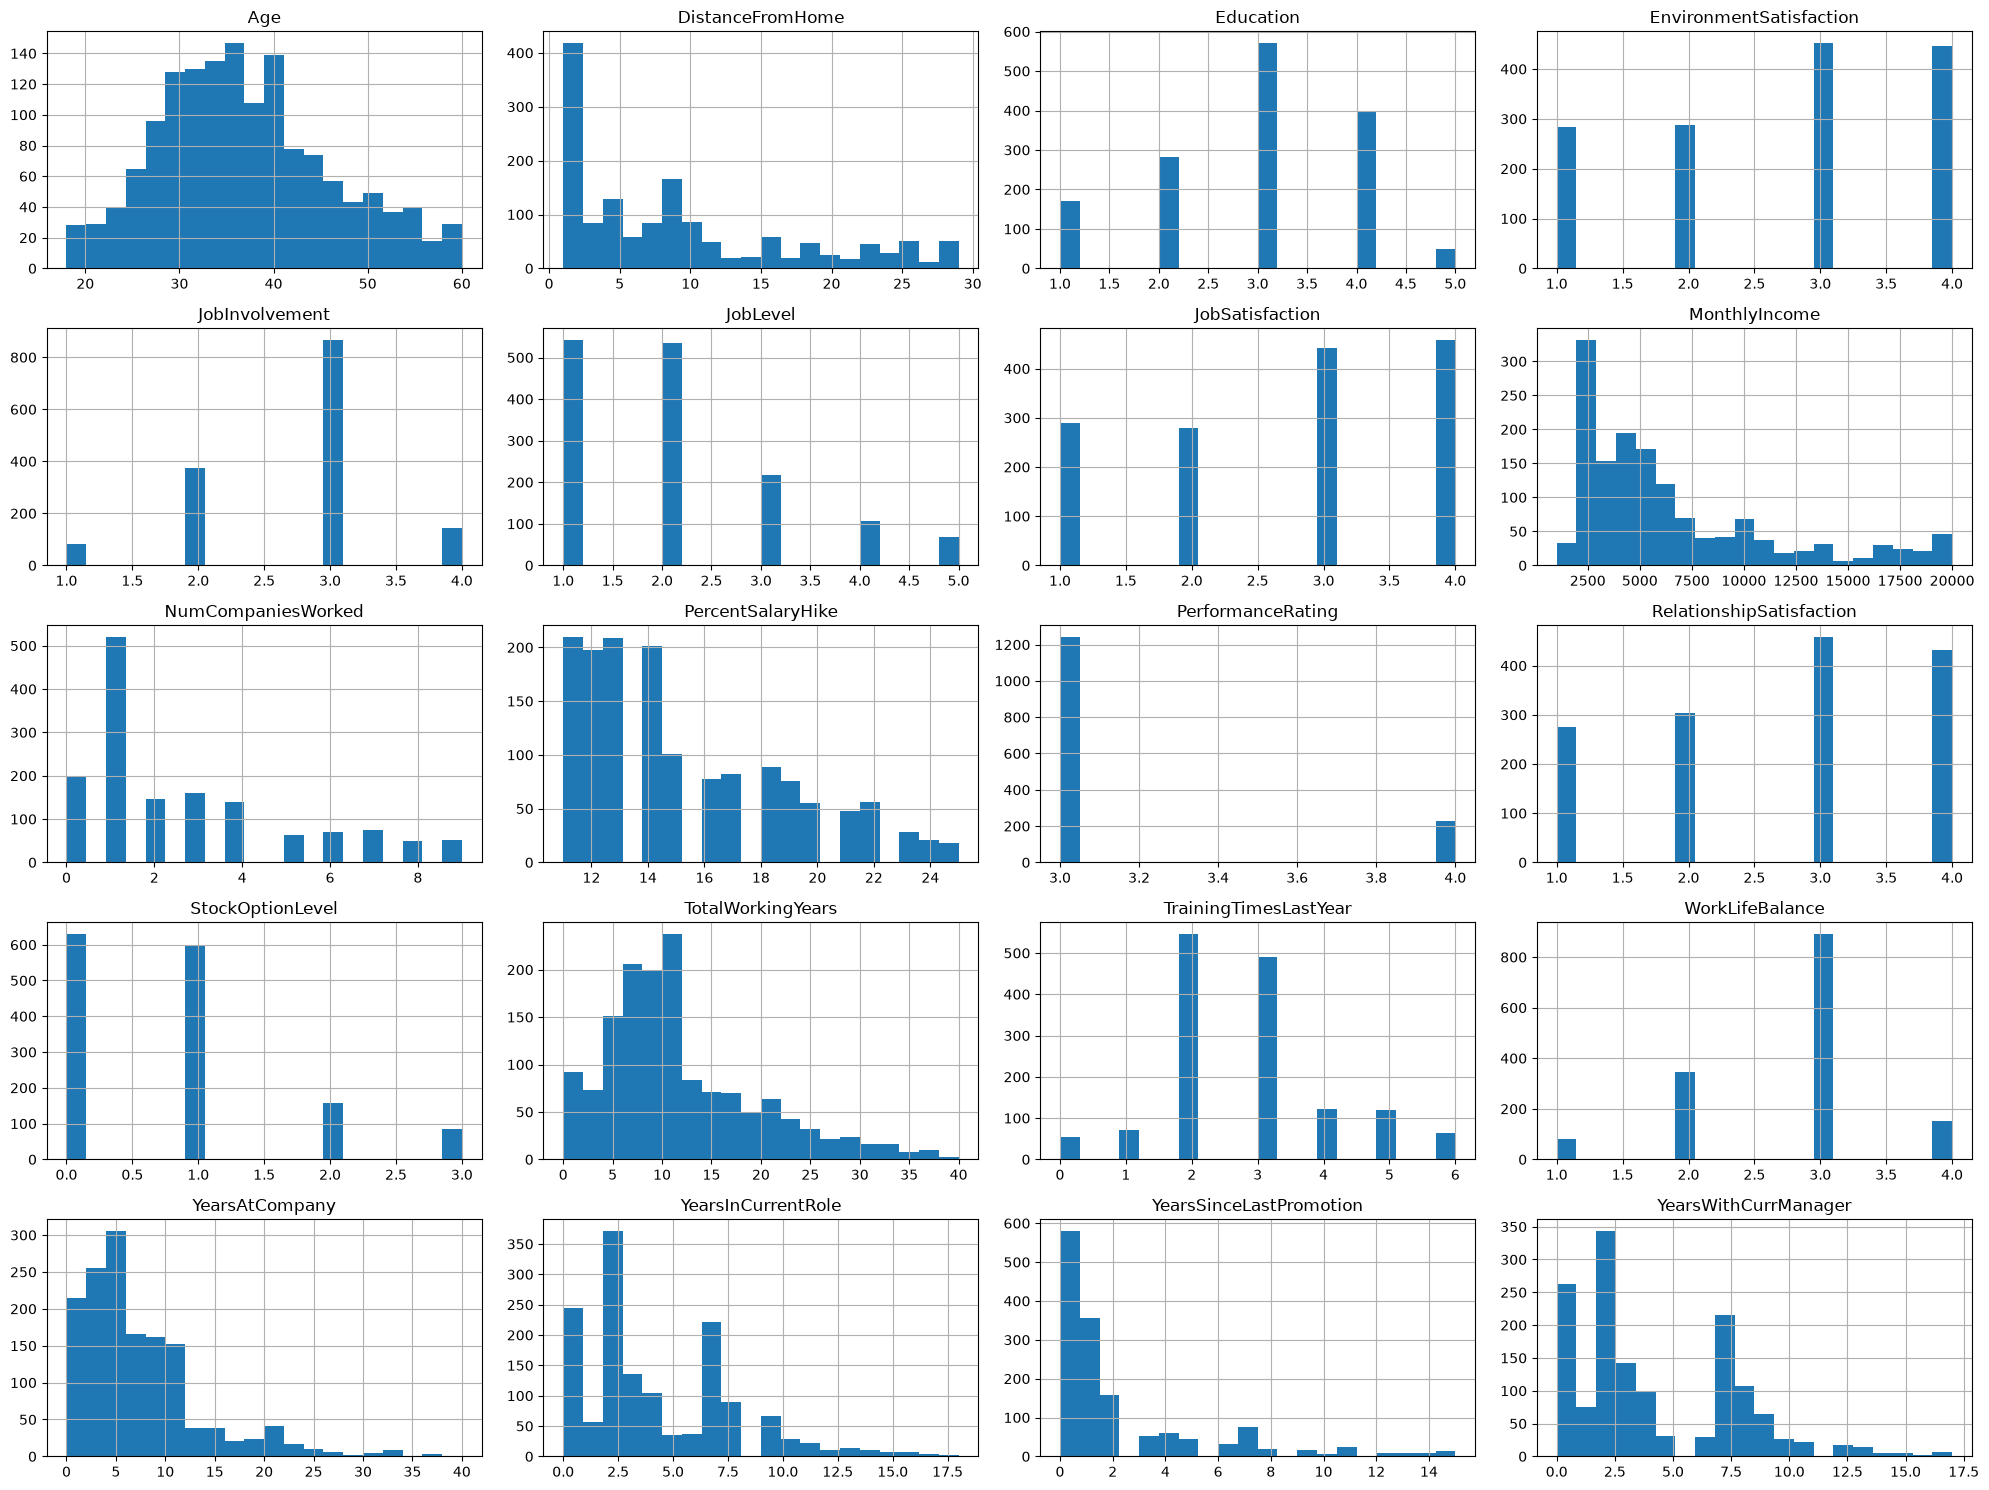

In [13]:
df.hist(figsize=(20,15),bins=20)
plt.tight_layout()
plt.show()

By the following histogram plottings of the numeric columns above we can conclude that

*   In the `age` graph we can clearly see that it is a normal distribution which is a very good sign for the company as the most number of employees belong to the age group of `30-40`. This indicates that the majority of the workforce are in their peak stage of career as they are still ambitious and have enough experience to make good decisions.
*   The salary range of `$2000-$3000` is the most paid salary as nearly `300+` employees earn in this range and also a lot of employees earn between `$3000-$7000`. Overall most number of employee fall under the salary bracket of `$2000-$7000` and consist of the major workforce of the company.

*   The total `working years` of the employees range from `0-40` where most employees are in the range of `0-15`. Employees having a work experience of `10-12` years constitute the major workforce and it is really beneficial to have them.


*   A lot of employees have been promoted very recently in last 2 years and we can also see that a lot of employees have been in this company from past `10 years` where a major chunk of employees have been since `5 years` and it is great that promotions have been done really well within the past 2 years








The above plots of `histogram `did show us a lot of distributions but we couldn't properly analyse histograms showing `discrete plottings` . So to counter this we will make a `countplot` and get the exact number of employees under each rating . It will involve columns based on **Satisfaction**, **Education**, **Performance rating** and **Work-Life-Balance** etc.
We will additionaly also run a `np.floor` to round of decimal values to integers for smooth plottings and convert the `numeric values` to `ordinal values`. 

In [14]:
#Satisfaction based columns mapped according to the official company data
sat_col = ['EnvironmentSatisfaction','JobSatisfaction','RelationshipSatisfaction']
sat_map = {1:'Low', 2:'Medium', 3:'High', 4:'Very High'}
for i in sat_col:
    df[f'{i}_label'] = np.floor(df[i]+0.5).astype('int64').map(sat_map) #np.floor is used to round of any decimal values present in dataset to prevent inconsistency.
# 0.5 is added to the column values to round off the values to nearest integer. For example, 1.2 will be rounded to 1 and 1.8 will be rounded to 2.
#Education based columns mapped according to the official company data.
edu_map = {1:'Below College', 2:'College', 3:'Bachelor', 4:'Master', 5:'Doctor'}
df['Education_label'] = np.floor(df['Education']+0.5).astype('int64').map(edu_map)

#Performance based columns mapped according to the official company data
per_map = {1:'Low', 2:'Good', 3:'Excellent', 4:'Outstanding'}
df['PerformanceRating_label'] = np.floor(df['PerformanceRating']+0.5).astype('int64').map(per_map)

#Work Life Balance based columns mapped according to the official company data
bal_map = {1:'Bad', 2:'Good', 3:'Better', 4:'Best'}
df['WorkLifeBalance_label'] = np.floor(df['WorkLifeBalance']+0.5).astype('int64').map(bal_map)


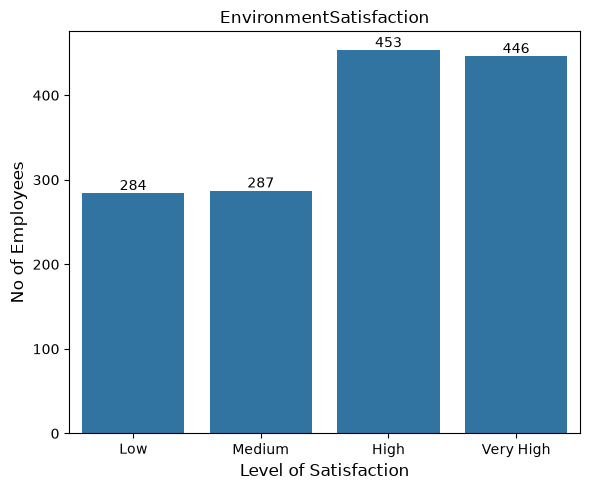

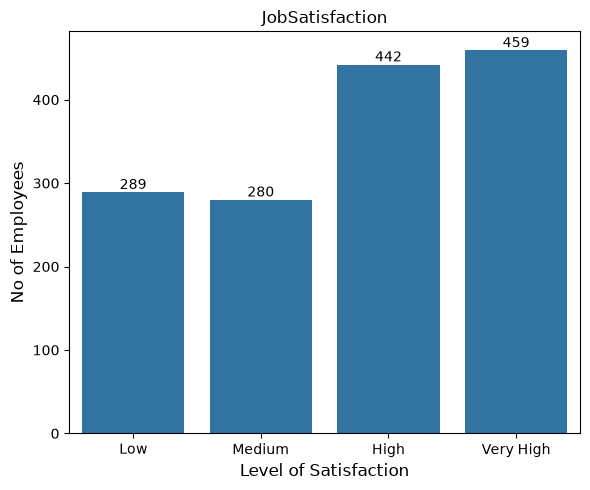

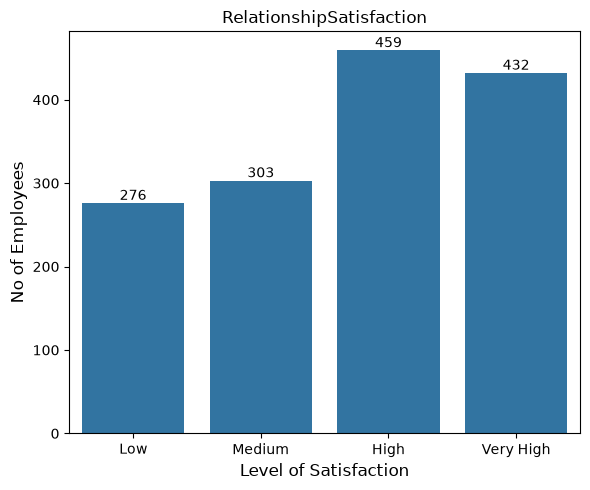

In [15]:
# For Satisfaction based plots
sat_order = ['Low', 'Medium', 'High', 'Very High']
for i in sat_col :
    plt.figure(figsize=(6, 5))
    graph = sns.countplot(data=df, x=(f'{i}_label'), order=sat_order)
    graph.bar_label(graph.containers[0])
    plt.title(f'{i}')
    plt.xlabel('Level of Satisfaction',fontsize=12)
    plt.ylabel('No of Employees', fontsize=12)
    plt.tight_layout()
    plt.show()

By looking upon the **countplots** for the **level of satisfaction** of employees we can conclude that :
* `~900` employees constituting `~60%` of our workforce are highly or very highly satisfied with the company's work environment, while `~40%` of our employees are either not very much satisfied or moderately satisfied with the work environment.
* The similar pattern can also be seen on the plot of **Job Satisfaction** and **Relationship Satisfaction** as well.

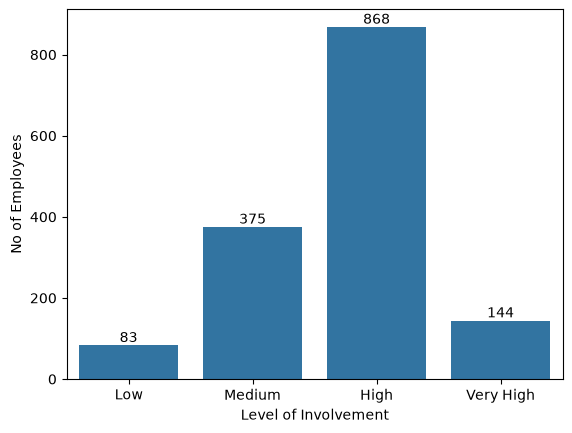

In [16]:
df['JobInvolvement_label']= np.floor(df['JobInvolvement']+0.5).astype('int64').map(sat_map)
graph = sns.countplot(data=df, x='JobInvolvement_label',order=sat_order)
graph.bar_label(graph.containers[0])
plt.xlabel("Level of Involvement")
plt.ylabel("No of Employees")
plt.show()

By the data from the above `countplots` we can get information about the **satisaction** and **involvement** of the **employees** and conclude that :

*  `868` employees which constitutes of about *~60%* of our workforce are highly involved in their respective jobs.
*  It simply means that every `3 in 5` employees are working hard and it is very good for the productivity of this company.
*  On top of *~60%* hardworking employees there are `144` very hardowrking employees consisting of *~10%* of our workforce.
*  So, overall we can conclude that an approximate of `~70%` of the employees are hardoworking which is a positive.

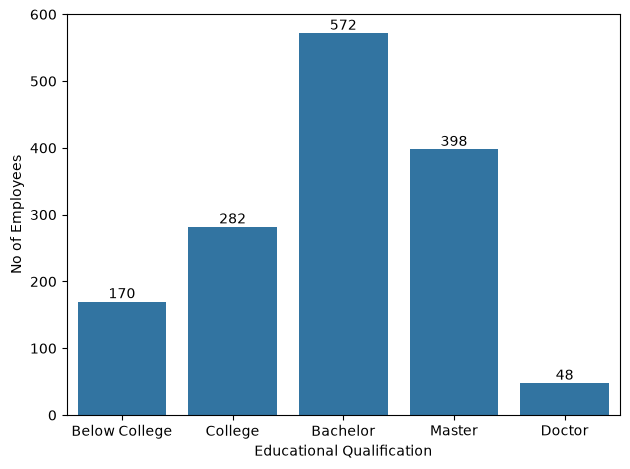

In [17]:
#Plotting for educational qualifications
edu_order = ['Below College', 'College', 'Bachelor', 'Master', 'Doctor']
graph = sns.countplot(data = df, x ='Education_label', order=edu_order)
graph.bar_label(graph.containers[0])
plt.xlabel("Educational Qualification")
plt.ylabel("No of Employees")
plt.Figure(figsize=(6,6))
plt.tight_layout()
plt.show()

By the above **countplot** we get an overview of the educational qualifications of our **employees**:
* `~38%` of the employees have bachelor's degree and it is the majority.
* `~27%` of the employees have a master's degree.
* `~19%` of the employees have a college degree.
* `~11%` of the employees have an education level of below college.
* `~3%`  of the employees have a doctorate level qualification.

[]

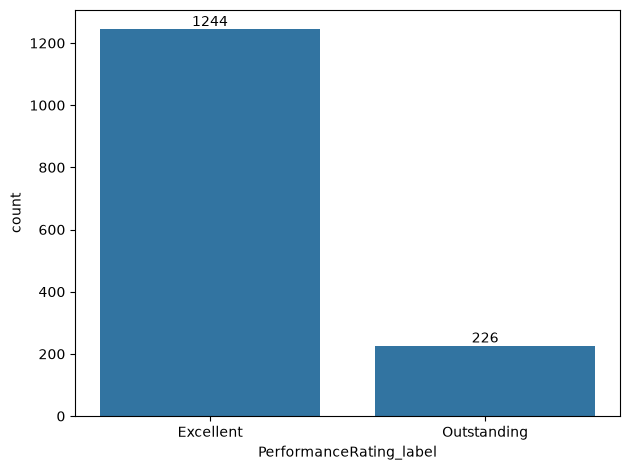

In [18]:
#Plotting for Performance Rating
per_order=['Low','Good','Excellent','Outstanding']
graph = sns.countplot(data= df, x='PerformanceRating_label', order=per_order)
graph.bar_label(graph.containers[0])
plt.Figure(figsize=(6,6))
plt.tight_layout()
plt.plot()

The **Performance Ratings** of the employees have been either `Excellent` or `Outstanding`
* **Excellent**: `~84.5%` of the employees have been Excellent.
* **Outstanding**: `~15.5%` of the employees have been Outstanding.

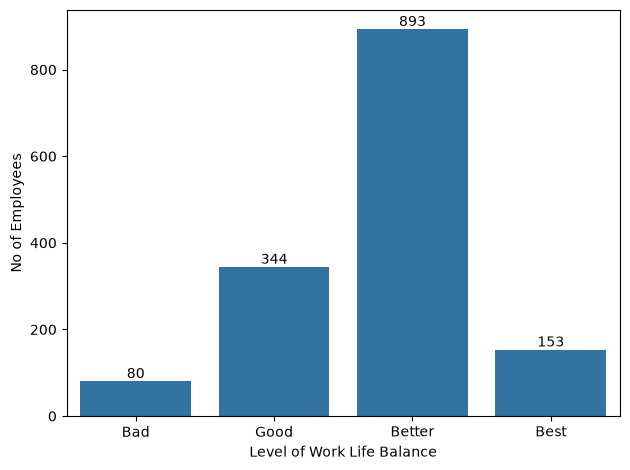

In [19]:
#Work life balance Plotting
bal_order = ['Bad','Good','Better','Best']
graph = sns.countplot(data=df, x='WorkLifeBalance_label', order=bal_order)
graph.bar_label(graph.containers[0])
plt.xlabel('Level of Work Life Balance')
plt.ylabel('No of Employees')
plt.Figure(figsize=(6,6))
plt.tight_layout()
plt.show()

By the above **countplot** we get that:
* **Better**: `893` employees who constitues `~60%` of the workforce are having better "work-life-balance".
* **Good**  : `344` employees who constitues `~23.5%` of the workforce are having good "work-life-balance".
* **Best**  : `153` employees who constitues `~10.5%` of the workforce are having best "work-life-balance".
* **Bad**   : `80`  employees who constitues `~5.5%` of the workforce are having bad "work-life-balance".

* **Positives**: `1390` employees who constitues `~94.5%` of the workforce are having Satisfactory "work-life-balance".
* **Negatives**: `80` employees who constitues `~5.5%` of the workforce are not having Satisfactory "work-life-balance".

We will be checking ahead that weather these employees having Bad Work Life Balance tend to leave the company or not.

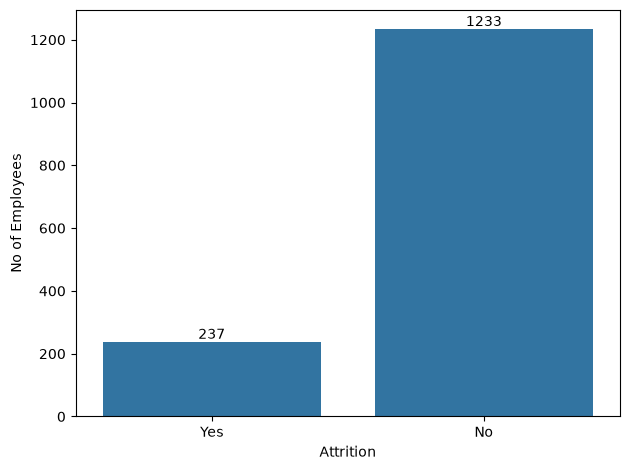

In [20]:
#Attrition Plotting 
at_order = ['Yes','No']
graph = sns.countplot(data=df, x='Attrition', order=at_order)
graph.bar_label(graph.containers[0])
plt.xlabel("Attrition")
plt.ylabel("No of Employees")
plt.Figure(figsize=(6,6))
plt.tight_layout()
plt.show()

The `Attrition` of the employees are as follows:
* **Yes**: `237` employees have left the company which accounts for `~16%`of the workforce.
* **No**: `1233` employees are still in the company accounting for `~84%` of the workforce.

> In the `Bivariate` analysis we will check exactly what other factors and variables are responsible for employee Attrition.

**Bivariate Analysis**

Department wise Attrition

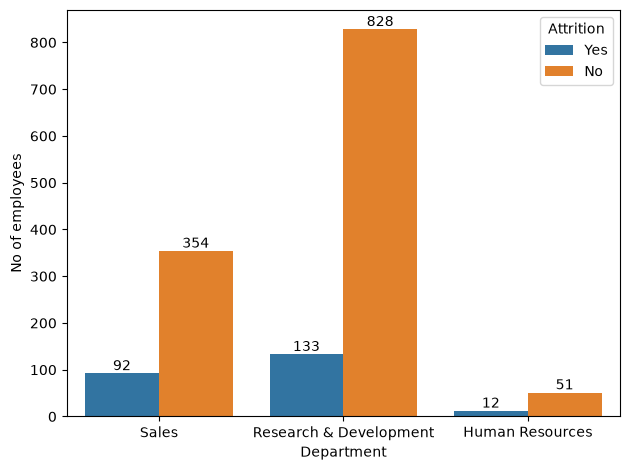

In [21]:
graph = sns.countplot(data=df, x="Department", hue="Attrition")
graph.bar_label(graph.containers[0])
graph.bar_label(graph.containers[1])
plt.xlabel("Department")
plt.ylabel("No of employees")
plt.tight_layout()
plt.show()

Attrition of Employees per department:
* **Research and Development** : The attrition rate is `16%` and total employees left is 133.
* **Sales** : The attrition rate is `26%` and total employees left is 92.
* **Human Resources** : The attrition rate is `41%` and total employees left is 12.

* This is really an alarming situation in the HR department as attrition rate is so high and it is really unsustainable for a department responsible for managing the entire workforce.
* R&D department has the least attrition rate but in terms of volume it is a topic to be worried about.
* Although Sales department has moderate attrition rate but it is a significant department which handles clients relationships and can affect companies revenue too.

Job Role wise Attrition

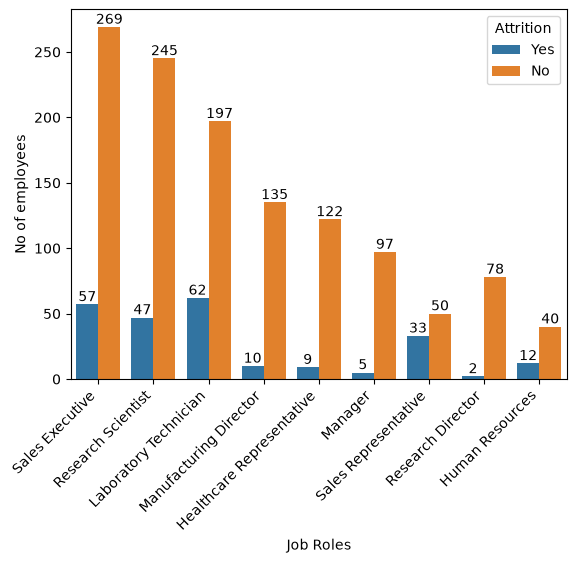

In [22]:
graph = sns.countplot(data=df, x="JobRole", hue="Attrition")
graph.bar_label(graph.containers[0])
graph.bar_label(graph.containers[1])
plt.xlabel("Job Roles")
plt.ylabel("No of employees")
plt.xticks(rotation=45, ha ="right")
plt.show()

In terms of Job Roles :
* **Highest Absolute Attrition**: Laboratory Technician recorded the highest number of departures which is 62  closely followed by Sales Executive 57 and Research Scientist 47.

* **Highest Attrition Rate**: Sales Representative exhibits the highest percentage rate of attrition (~39.8%), with 33 departures out of 83 total employees.

* **Lowest Attrition**: Research Director has the lowest turnover both in volume (2 employees) and rate (~2.5%), followed by Manager (5 departures, ~4.9%).

Education wise Attrition

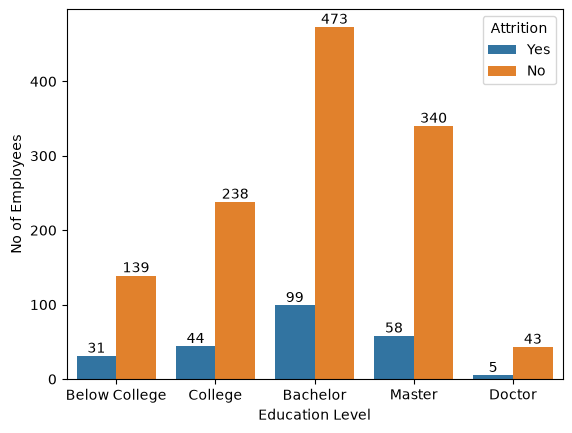

In [23]:
graph = sns.countplot(data=df, x="Education_label", hue="Attrition", order= edu_order)
graph.bar_label(graph.containers[0])
graph.bar_label(graph.containers[1])
plt.xlabel("Education Level")
plt.ylabel("No of Employees")
plt.show()

In terms of education:
* **Highest Absolute Attrition**: Employees with a Bachelor degree recorded the highest number of departures (99), making up the largest demographic in the workforce (572 total employees).

* **Highest Attrition Rate**: Employees with a Below College education level exhibited the highest percentage rate of attrition (~18.2%), followed by those with a Bachelor degree (~17.3%).

* **Lowest Attrition**: Employees holding a Doctor degree had the lowest turnover both in total volume (5 employees) and rate (~10.4%).

Marital Status wise Attrition

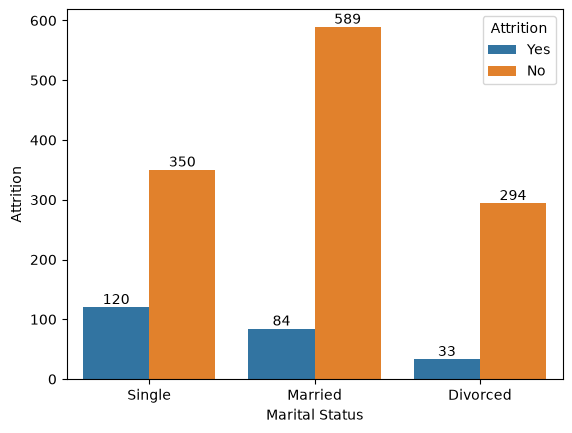

In [24]:
graph = sns.countplot(data=df, x="MaritalStatus", hue="Attrition")
graph.bar_label(graph.containers[0])
graph.bar_label(graph.containers[1])
plt.xlabel("Marital Status")
plt.ylabel("Attrition")
plt.show()

In terms of Marital Status :
* **Highest Absolute Attrition**: Single employees recorded the highest number of departures (120), despite having a smaller total workforce than married employees.

* **Highest Attrition Rate**: Single employees exhibited the highest percentage rate of attrition (~25.5%), departing at double the rate of married employees and more than double that of divorced employees.

* **Lowest Attrition**: Divorced employees had the lowest turnover both in total volume (33 departures) and percentage rate (~10.1%).

Over Time duty wise Attrition:

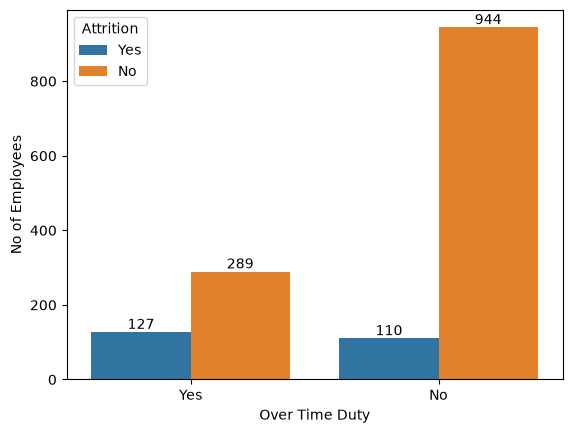

In [25]:
graph = sns.countplot(data=df, x="OverTime", hue="Attrition")
graph.bar_label(graph.containers[0])
graph.bar_label(graph.containers[1])
plt.xlabel("Over Time Duty")
plt.ylabel("No of Employees")
plt.show()


Over Time Duty wise Attrition:
* **Impact of Overtime on Attrition Rate**: Employees who perform overtime work experience an attrition rate of 30.5%, which is nearly triple the rate of employees who do not work overtime which is 10.4%.
* **Absolute Volume**: Despite making up less than 30% of the total workforce (416 out of 1,470 total employees), employees working overtime account for the majority of total departures (127 vs 110).

Work Life Balance wise Attrition:

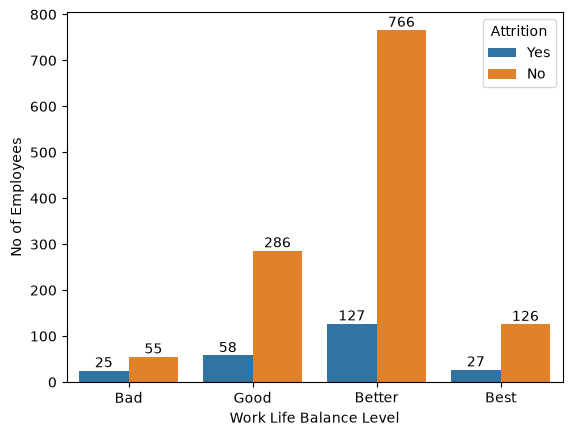

In [26]:

graph = sns.countplot(data = df, x="WorkLifeBalance_label", hue="Attrition", order=bal_order)
graph.bar_label(graph.containers[0])
graph.bar_label(graph.containers[1])
plt.xlabel("Work Life Balance Level")
plt.ylabel("No of Employees")
plt.show()

Role of Work Life Balance in Attrition:
* **Highest Attrition Rate**: Employees reporting a Bad work-life balance experience the highest turnover rate at 31.3% (25 out of 80 employees).

* **Dominant Workforce Category**: The vast majority of employees fall into the Better category (893 out of 1,470 total employees), which also records the lowest overall turnover rate at 14.2%.

* **Highest Absolute Volume**: The Better category has the highest total number of departures (127), purely due to its large baseline population.

Job Satisfaction wise Attrition:

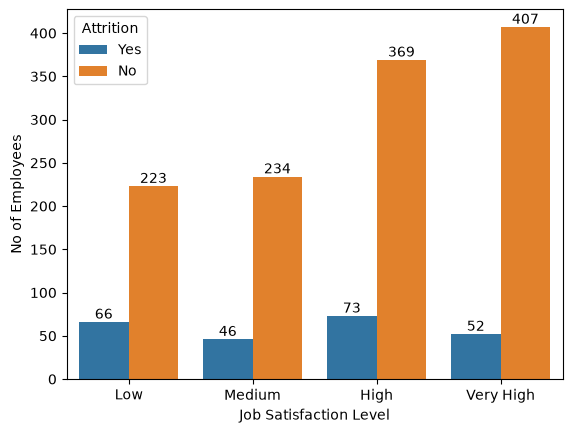

In [27]:
graph = sns.countplot(data= df, x= "JobSatisfaction_label", hue= "Attrition", order= sat_order)
graph.bar_label(graph.containers[0])
graph.bar_label(graph.containers[1])
plt.xlabel("Job Satisfaction Level")
plt.ylabel("No of Employees")
plt.show()

Role of Job Satisfaction Level in Attrition:
* **Highest Attrition Rate**: Employees reporting Low job satisfaction experience the highest percentage rate of attrition at 22.8% (66 out of 289 employees).

* **Lowest Attrition Rate**: Employees with Very High job satisfaction recorded the lowest turnover rate at 11.3% (52 out of 459 employees), nearly half the rate of the Low satisfaction group.

* **Highest Absolute Volume**: The High satisfaction category registered the highest absolute number of departures (73), driven primarily by its larger total employee base.

Environment Satisfaction wise Attrition:

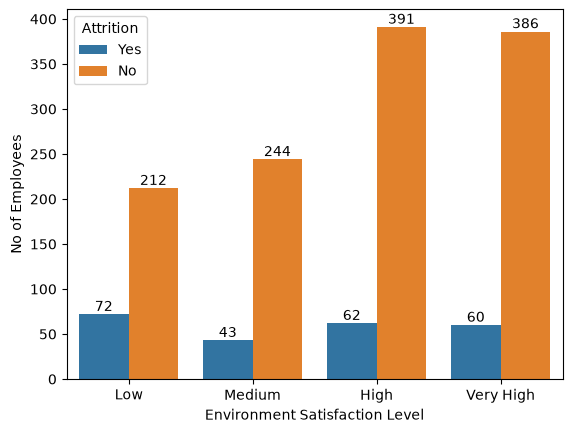

In [28]:
graph = sns.countplot(data= df, x= "EnvironmentSatisfaction_label", hue = "Attrition", order= sat_order)
graph.bar_label(graph.containers[0])
graph.bar_label(graph.containers[1])
plt.xlabel("Environment Satisfaction Level")
plt.ylabel("No of Employees")
plt.show()

Role of Environment Satisfaction:
* **Highest Attrition Rate**: Employees with Low environment satisfaction experience the highest percentage rate of attrition at 25.4% (72 departures out of 284 total employees).

* **Highest Absolute Volume**: The Low satisfaction group also registered the highest number of overall departures (72).

* **Impact of Higher Satisfaction**: Turnover drops significantly when environment satisfaction improves beyond Low dropping from 25.4% down to 15.0% for Medium, 13.7% for High, and reaching a low of 13.5% for Very High.

Age wise Attrition:

In [29]:
print(df["Age"].min())    #Done for calculating bin width
print(df["Age"].max())
print("Bin width = ", np.ceil((df["Age"].max()-df["Age"].min())/10))

18
60
Bin width =  5.0


[]

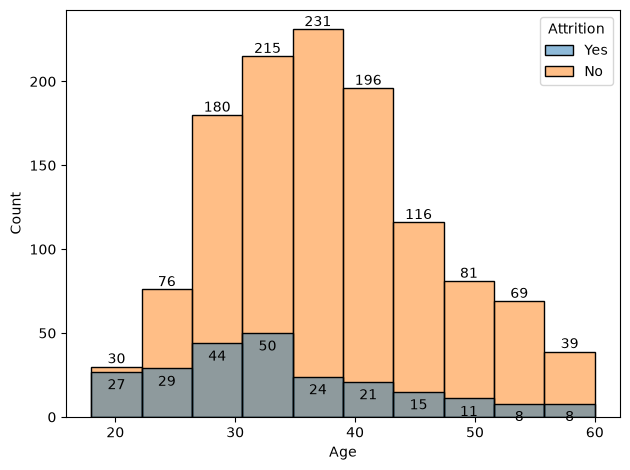

In [30]:
graph=sns.histplot(data=df, x="Age", hue="Attrition", bins=10)
graph.bar_label(graph.containers[0])
graph.bar_label(graph.containers[1],padding=-15)
plt.tight_layout()
plt.plot()


Role of Age in Attrition:
* **Highest Attrition Rate**: Younger employees aged 18 – 22 show the highest turnover rate at 47.4% (27 departures out of 57 total employees). Attrition steadily decreases as employee age increases.

* **Highest Absolute Departures**: The 33 – 37 age group recorded the highest total number of employee departures (50), closely followed by the 28 – 32 group (44).

* **Most Stable Age Groups**: Employees between 38 – 47 years old display the lowest turnover rates, remaining under 10%.

Monthly Income wise Attrition :


In [31]:
print(df["MonthlyIncome"].min())    #Done for calculating bin width
print(df["MonthlyIncome"].max())
print("Bin width = ", np.ceil((df["MonthlyIncome"].max()-df["MonthlyIncome"].min())/10))

1009
19999
Bin width =  1899.0


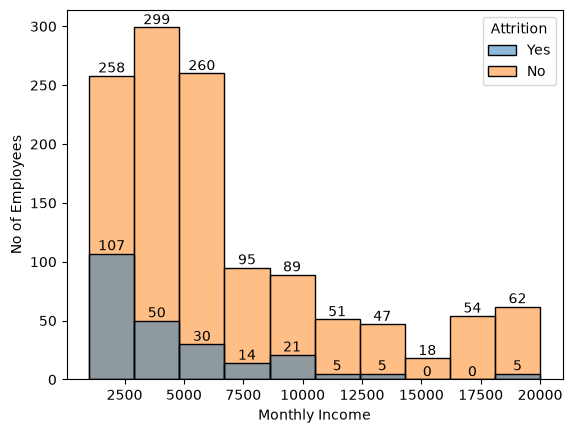

In [32]:
graph = sns.histplot(data=df, x="MonthlyIncome", hue="Attrition", bins=10)
graph.bar_label(graph.containers[0])
graph.bar_label(graph.containers[1])
plt.xlabel("Monthly Income")
plt.ylabel("No of Employees")
plt.show()


Role of Monthly Income in Attrition:
* **Highest Attrition Rate**: Employees in the lowest monthly income bracket ($1,000 – $3,000) experience the highest turnover rate at 29.3% (107 departures out of 365 employees).

* **Highest Absolute Volume**: The $1,000 – $3,000 income bracket also accounts for nearly half (107 out of 237) of all recorded employee departures.

* **High Earners Retention**: Employees earning between $15,000 and $19,000 show zero attrition (0%), indicating strong retention among higher earners.

* **Trend**: Attrition drops significantly as monthly income increases beyond $3,000.   


Working Years based Attrition:

In [33]:
print(df["TotalWorkingYears"].min())
print(df["TotalWorkingYears"].max())
print("Bin width = ", np.ceil((df["TotalWorkingYears"].max()-df["TotalWorkingYears"].min())/10))

0
40
Bin width =  4.0


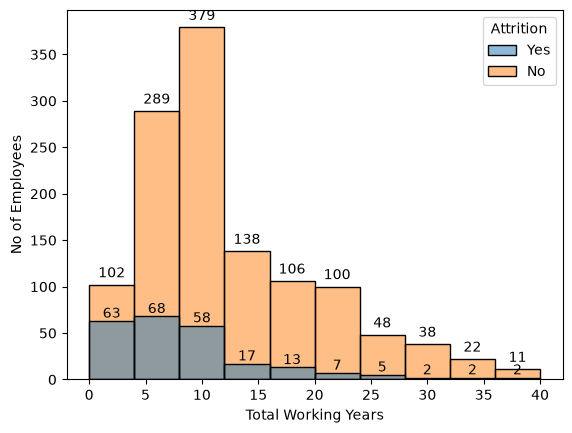

In [34]:
graph = sns.histplot(data= df, x= "TotalWorkingYears",hue= "Attrition", bins=10)
graph.bar_label(graph.containers[0], padding=3)
graph.bar_label(graph.containers[1])
plt.xlabel("Total Working Years")
plt.ylabel("No of Employees")
plt.show()

Role of Working Years in Attrition:
* **Highest Attrition Rate**: Freshers with 0 – 4 years of total working experience are responsible for  the highest turnover rate of 38.2% (63 departures out of 165 employees).

* **Highest Absolute Volume**: The 4 – 8 years experience bracket recorded the highest absolute number of departures (68), followed closely by the 0 – 4 years group (63).

* **Retention among Mid-to-Late Career Employees**: Employees with 8 to 24 total working years show significantly improved retention, with turnover rates consistently staying below 13.5%.

* **Trend**: Attrition drops sharply as an employee's total career longevity increases, stabilizing after the 8-year mark

Total Years at Company based Attrition:

In [35]:
print(df["YearsAtCompany"].min())
print(df["YearsAtCompany"].max())
print("Bin width = ", np.ceil((df["YearsAtCompany"].max()-df["YearsAtCompany"].min())/10))

0
40
Bin width =  4.0


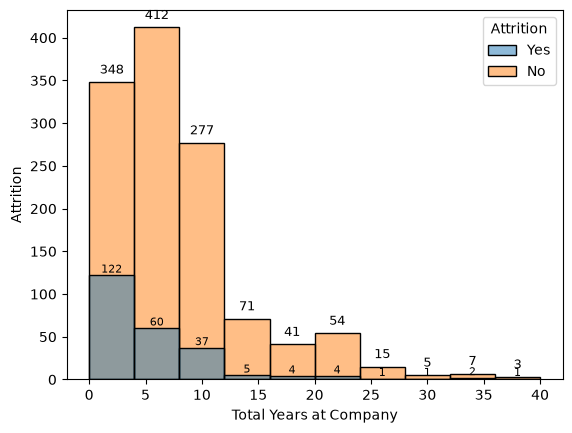

In [36]:
graph= sns.histplot(data=df, x="YearsAtCompany", hue= "Attrition", bins=10)
graph.bar_label(graph.containers[0], padding=4, fontsize=9)
graph.bar_label(graph.containers[1],fontsize=8)
plt.xlabel("Total Years at Company")
plt.ylabel("Attrition")
plt.show()

Role of Total Years at Company based Attrition:

* **Highest Absolute Departures**: Employees in their first 0 – 4 years with the company account for the vast majority of turnover (122 departures out of 237 total across the company).

* **Highest Attrition Rate**: The 0 – 4 years tenure bracket experiences the highest attrition rate at 26.0%.

* **Significant Retention Drop-off**: Once an employee passes their 4th year at the company, turnover drops by more than half—falling to 12.7% in years 4 – 8 and continuing down to 6.6% in years 12 – 16.

* **Tenure Stability**: Employees with 4 to 28 years of tenure at the company demonstrate high stability, with attrition rates generally remaining below 13%.

Distance From Home Based Attrition:

In [37]:
print(df["DistanceFromHome"].min())
print(df["DistanceFromHome"].max())
print("Bin width = ", np.ceil((df["DistanceFromHome"].max()-df["DistanceFromHome"].min())/10))

1
29
Bin width =  3.0


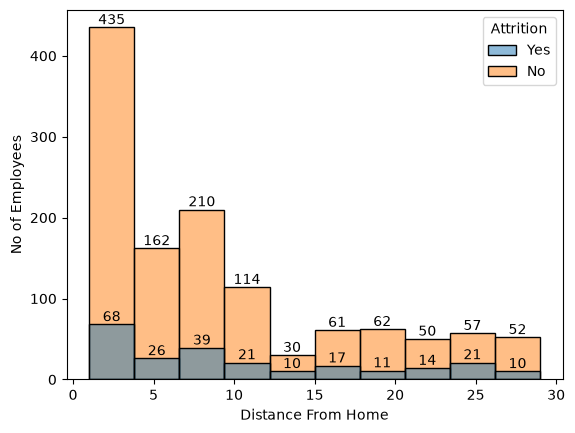

In [38]:
graph = sns.histplot(data= df, x="DistanceFromHome", hue= "Attrition", bins=10)
graph.bar_label(graph.containers[0])
graph.bar_label(graph.containers[1])
plt.xlabel("Distance From Home")
plt.ylabel("No of Employees")
plt.show()

Role of Distance from Home in Attrition:
* **Highest Absolute Departures**: Employees living closest to work (1 – 4 miles) account for the highest volume of departures (68), primarily due to this group representing the largest segment of the total workforce (503 employees).

* **Highest Attrition Rates**: Employees commuting longer distances generally experience higher rates of turnover, peaking at 26.9% for the 25 – 28 range and 25.0% for the 13 – 16 range.

* **Trend**: Attrition rates remain lower and stable (~13.5% – 15.7%) for employees living within 10 miles, but jump noticeable for commutes exceeding 13 miles.


Number of Companies based Attrition:


In [39]:
print(df["NumCompaniesWorked"].min())
print(df["NumCompaniesWorked"].max())
print("Bin width = ", np.ceil((df["NumCompaniesWorked"].max()-df["NumCompaniesWorked"].min())/10))

0
9
Bin width =  1.0


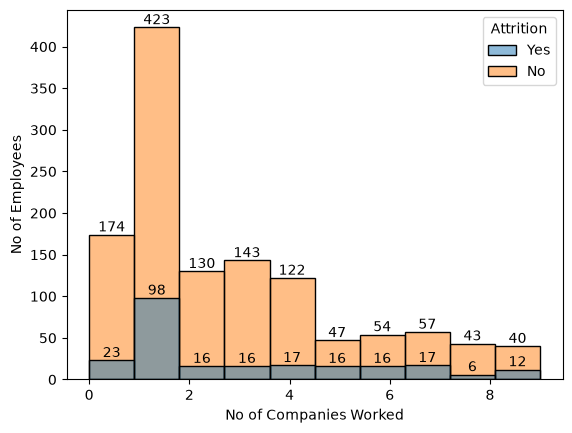

In [42]:
graph = sns.histplot(data= df, x="NumCompaniesWorked", hue="Attrition", bins=10)
graph.bar_label(graph.containers[0])
graph.bar_label(graph.containers[1])
plt.xlabel("No of Companies Worked")
plt.ylabel("No of Employees")
plt.show()

Role of No of Companies Worked in Attrition:

* **Highest Absolute Departures**: Employees who have worked at 1 company prior to this one account for the vast majority of turnover in absolute volume (98 departures out of 237 total across the company).

* **Job Hopper Risk Factor**: Employees who have worked at 5 or more companies exhibit a sharp increase in turnover rate, averaging between 22.9% and 25.4% attrition (with the exception of 8 companies at 12.2%).

* **Mid-Range Retention**: Employees who have worked at 2 to 4 prior companies display the strongest stability, with attrition rates staying below 12.3%.

* **First-Job Loyalty**: Employees with 0 prior companies (freshers) show a relatively low attrition rate of 11.7%.

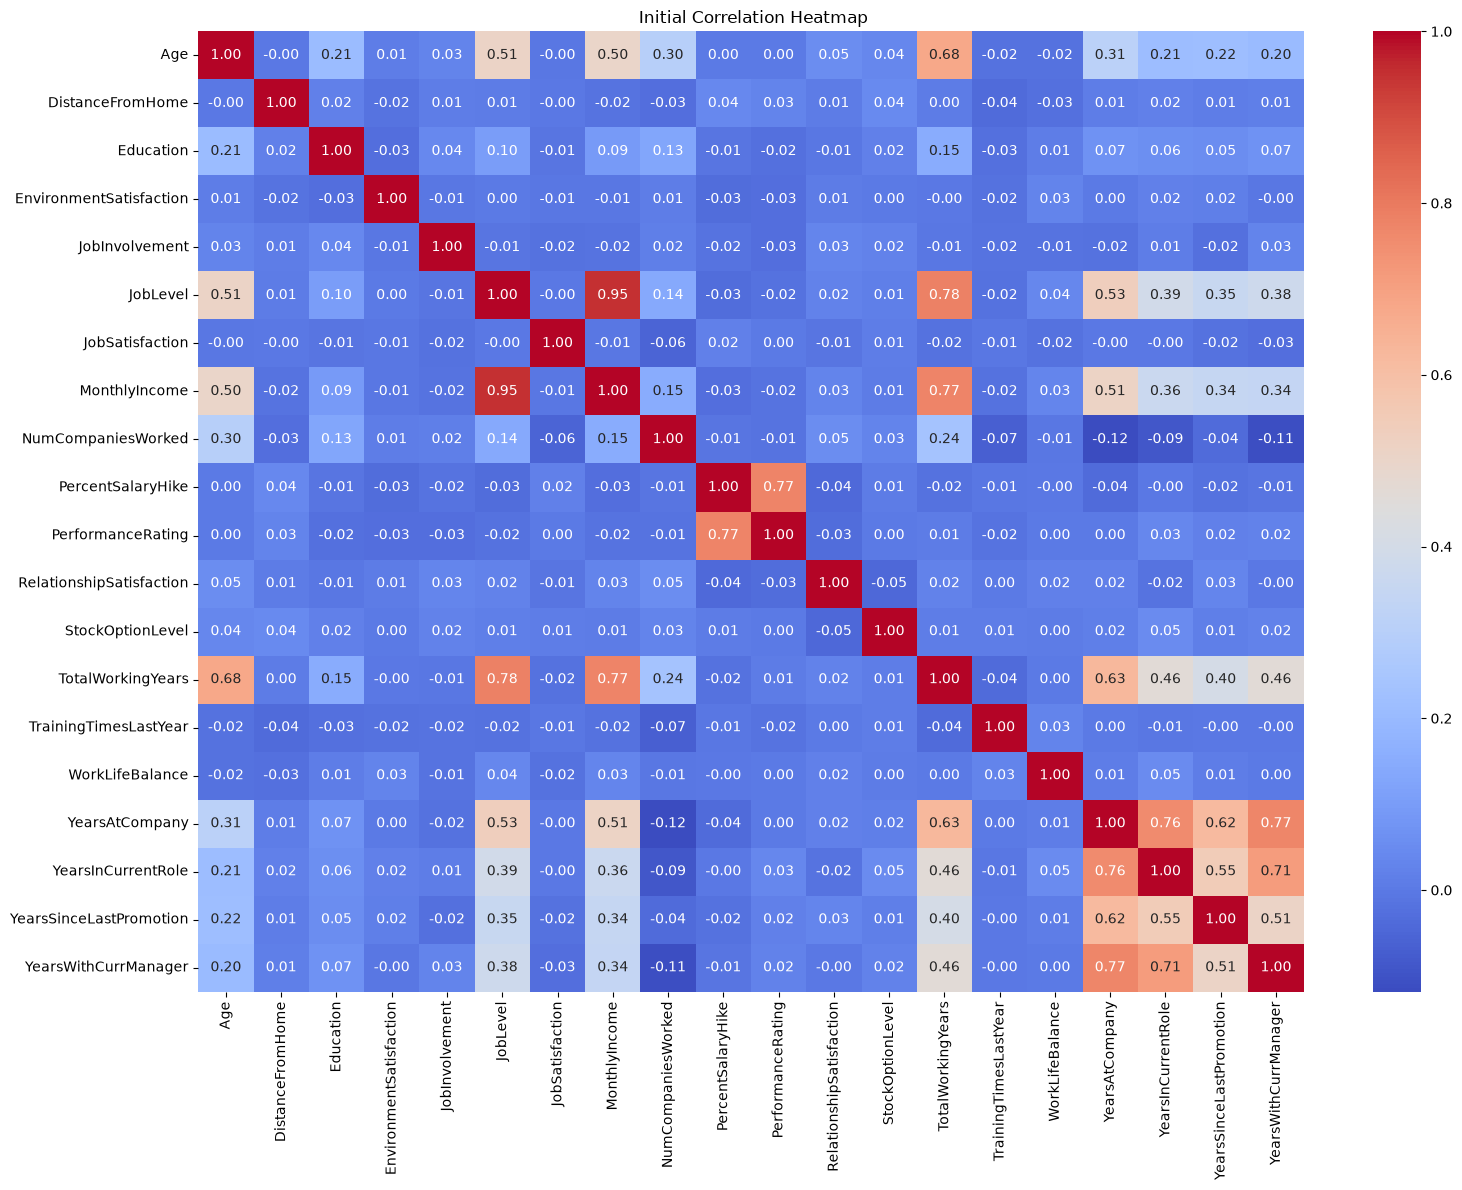

In [50]:
plt.figure(figsize=(16,12))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title(' Initial Correlation Heatmap')
plt.tight_layout()
plt.show()

Key Observations:
* **Strong Multi-Collinearity Identified:**
1) `JobLevel` vs. `MonthlyIncome` ($0.95$): Almost a perfect positive linear correlation, confirming that higher job roles directly map to higher pay.

2) `TotalWorkingYears` vs. `JobLevel` ($0.78$) & `MonthlyIncome` ($0.77$): Clear career progression structure where cumulative industry experience drives seniority and earnings.

3) `YearsAtCompany` vs. `YearsInCurrentRole` ($0.76$) & `YearsWithCurrManager` ($0.77$): Demonstrates internal retention clustering.

4) `PercentSalaryHike` vs. `PerformanceRating` ($0.77$): Indicates salary hikes are closely tied to formal performance evaluations.

This initial heatmap has missing target variable which is Attrition and there is some redundancy which we will resolve in the final heat map.

Final Heat Map:

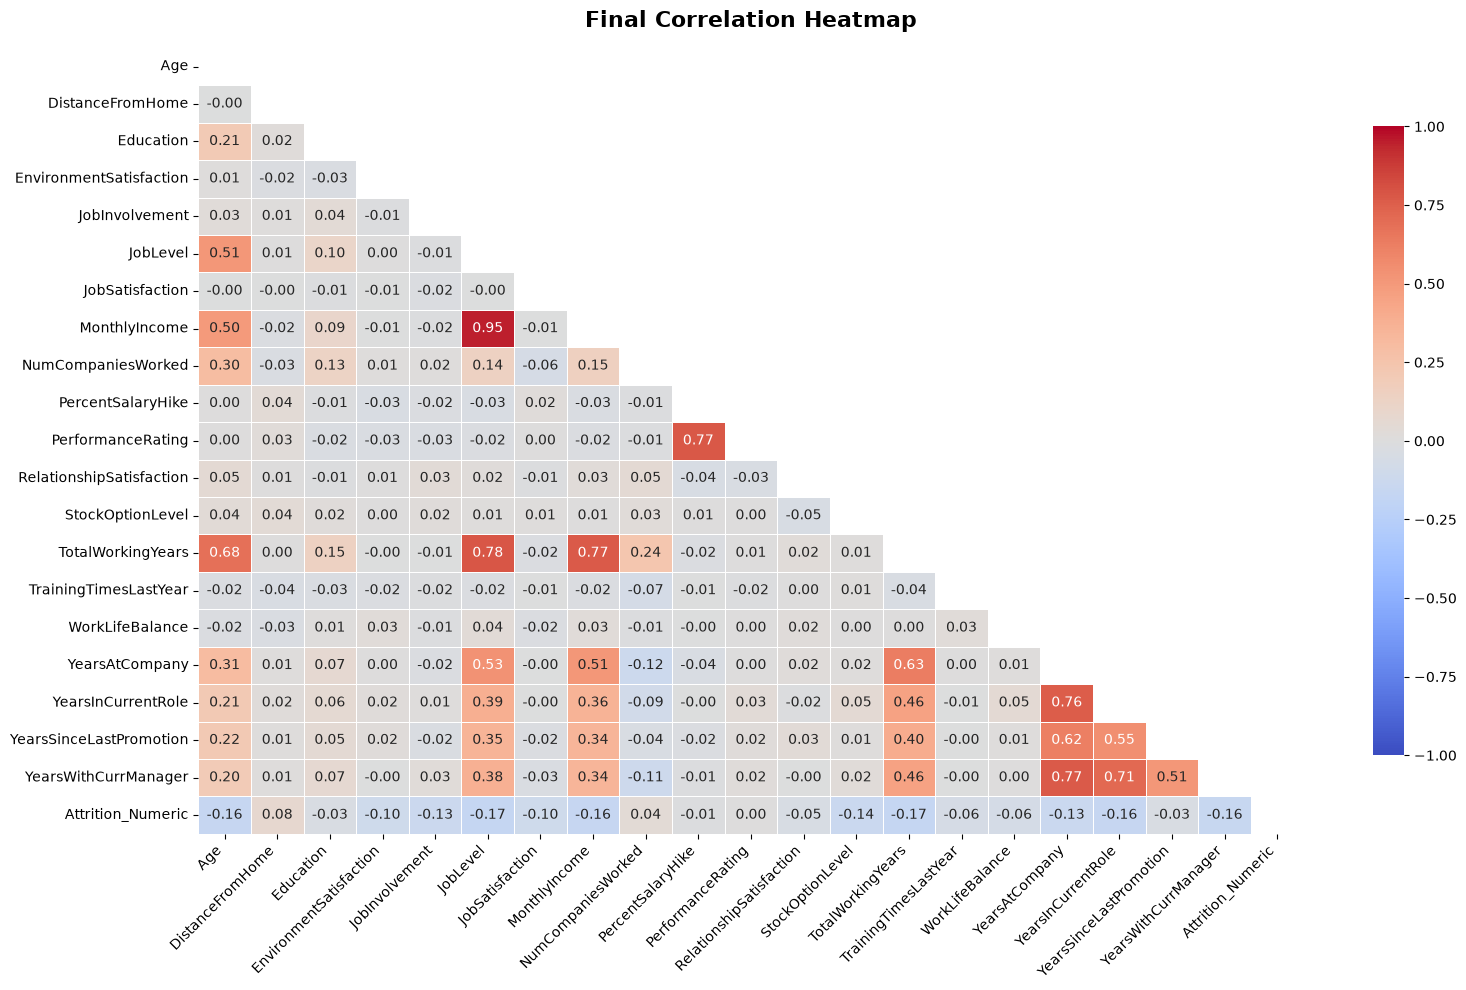

In [53]:
df_corr_data = df.select_dtypes(include=[np.number]).copy()
if "Attrition" in df.columns:
    df_corr_data["Attrition_Numeric"] = df["Attrition"].apply(lambda x: 1 if x == "Yes" else 0)

plt.figure(figsize=(16, 10))
mask = np.triu(np.ones_like(df_corr_data.corr(), dtype=bool))

sns.heatmap(
    df_corr_data.corr(),
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmax=1,
    vmin=-1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Final Correlation Heatmap", fontsize=16, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Here we have converted Attrition from String to Numeric for heatmap correlation.

Key Insights & Linear Correlations:
* **Target Variable Correlations (Attrition_Numeric)**:

1. **Negative Predictors of Attrition**: TotalWorkingYears ($-0.17$), JobLevel ($-0.17$), MonthlyIncome ($-0.16$), Age ($-0.16$), YearsInCurrentRole ($-0.16$), and YearsWithCurrManager ($-0.16$) show the strongest negative correlations with turnover. This indicates that senior, higher-earning, and longer-tenured staff exhibit higher retention.

2. **Positive Predictors of Attrition**: DistanceFromHome ($+0.08$) and NumCompaniesWorked ($+0.04$) show positive linear associations with attrition, aligning with higher flight risks for longer commutes and frequent job changers.

## Key Business Findings & Recommendations

###  High Risk Attrition Factors:
* **Overtime** is the strongest attrition driver , employees working overtime 
leave at `30.5%` rate, nearly **triple** the rate of non-overtime employees (`10.4%`).
* **Young employees aged 18-22** show the highest turnover rate of `47.4%` , 
almost every 1 in 2 young employees is leaving.
* **Low income employees earning $1,000-$3,000** account for nearly **half** 
of all departures (`107 out of 237`) with an attrition rate of `29.3%`.
* **Sales Representatives** exhibit the highest role-based attrition rate 
of `~39.8%` posing a direct risk to company revenue.

###  Moderate Risk Factors:
* **HR Department** has an alarming attrition rate of `41%` which is 
unsustainable for a department responsible for managing the entire workforce.
* **Single employees** leave at `~25.5%` rate — double that of married employees.
* **Freshers with 0-4 years** of experience account for the highest volume 
of departures (`122 out of 237`) with a `26%` attrition rate.
* **Long distance commuters** travelling beyond `13 miles` show noticeably 
higher attrition rates peaking at `26.9%`.

###  Positive Retention Indicators:
* **High earners above $15,000** show `0%` attrition — compensation is a 
strong retention tool.
* **Employees with 4+ years** at the company show dramatically improved 
retention dropping below `13%` attrition rate.
* **~70%** of employees are highly involved in their work indicating a 
largely engaged and productive workforce.
* **Research Directors and Managers** show the lowest role-based attrition 
at `~2.5%` and `~4.9%` respectively.



###  Recommendations:
* Revisit **overtime policies** — the data strongly suggests burnout is 
a primary attrition driver.
* Introduce **early career retention programs** targeting employees in 
their first 4 years.
* Review **compensation structure** for lower income brackets and 
Sales Representatives.
* Address **HR department burnout** as losing HR staff creates a 
compounding retention problem across the entire organization.